<a href="https://www.kaggle.com/code/azharalisoomro/lab-5-advanced-regression-techniques?scriptVersionId=349522866" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
**Name:Azhar Ali**
**Student ID: 023-24-0521**
**Section:B**
**GitHub:**
**Kaggle:**
**Dataset:** House Prices — Advanced Regression Techniques
**Dataset Source:** Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?


2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

**Answer 1:**
This dataset allows us to predict the final sale price of a house based on its various features, such as location, size, and condition. This is highly useful for real estate agents, buyers, and sellers to estimate fair market values and make informed financial decisions

**Answer 2:**
This is a regression problem because our target variable (SalePrice) is a continuous numerical value, rather than a discrete category like 'Yes' or 'No'. Consequently, instead of using classification metrics like accuracy or F1-score, we must evaluate the model using error-based metrics such as Mean Absolute Error (MAE) or Root Mean Squared Error (RMSE) to see how far off our price predictions are.

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [2]:
# Task 3 — load and inspect the dataset

import pandas as pd

# 1. Load the dataset
train_df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

# 2. Check the shape (rows, columns)
print("--- Shape of the Dataset ---")
print(train_df.shape)

# 3. View the first few rows
print("\n--- First 5 Rows ---")
display(train_df.head())

# 4. Check data types and missing values
print("\n--- Dataset Info ---")
train_df.info()

# 5. Summary statistics for numerical columns
print("\n--- Summary Statistics ---")
display(train_df.describe())

--- Shape of the Dataset ---
(1460, 81)

--- First 5 Rows ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: SalePrice

Numerical independent variables: OverallQual, GrLivArea, TotalBsmtSF, GarageCars, YearBuilt

Categorical independent variables: Neighborhood, ExterQual, KitchenQual, Foundation, BldgType

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [3]:
# 1. Target (y) aur Features (X) ko alag karein
y = train_df['SalePrice']
X = train_df.drop('SalePrice', axis=1)

# 2. Categorical variables ko One-Hot Encoding ke zariye numeric banayein
# drop_first=True lagana zaroori hai taake dummy variable trap se bacha ja sake
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Agar koi missing values reh gayi hain toh unhein 0 (ya median) se fill karein
X_final = X_encoded.fillna(0)

# Task 7: Confirm karein ke data fully numeric hai aur koi missing value nahi
print("Total Missing Values in X:", X_final.isnull().sum().sum())
print("Data Types:\n", X_final.dtypes.value_counts())

Total Missing Values in X: 0
Data Types:
 bool       208
int64       34
float64      3
Name: count, dtype: int64


## Numerical Features
**OverallQual** (Overall Quality): Rates the overall material and finish of the house on a 1 to 10 scale.

**GrLivArea** (Above Grade Living Area): The total living space (in square feet) that is above ground level (excluding the basement).

**TotalBsmtSF** (Total Basement Square Feet): The total area of the basement in square feet.

**GarageCars** (Garage Car Capacity): The size of the garage, measured by how many cars can fit inside.

**YearBuilt** (Original Construction Year): The exact year the house was originally constructed.

## Categorical Features
**Neighborhood** (Neighborhood): The specific location, society, or physical district within the city where the house is situated.

**ExterQual** (Exterior Material Quality): Rates the quality of the materials used on the outside of the house (e.g., Excellent, Good, Fair).

**KitchenQual** (Kitchen Quality): Rates the overall quality, finish, and condition of the kitchen.

**Foundation** (Foundation Type): The structural material used for the base of the house (e.g., Poured Concrete, Cinder Block).

**BldgType** (Building Type): Describes the structural layout of the property (e.g., Single-family detached, Duplex, Townhouse).

In [4]:
# Task 5 — define X and y, encode categorical columns
num_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt']
cat_features = ['Neighborhood', 'ExterQual', 'KitchenQual', 'Foundation', 'BldgType']

X = train_df[num_features + cat_features].copy()
y = train_df['SalePrice']

X[num_features] = X[num_features].fillna(0)
X[cat_features] = X[cat_features].fillna('None')

#Categorical columns converting into One-hot Coding
X = pd.get_dummies(X, columns=cat_features, drop_first=True)



In [5]:
# Task 7 — confirm X is fully numeric with no missing values
print(X.info())
print("\nTotal Missing Values in X:", X.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   OverallQual           1460 non-null   int64
 1   GrLivArea             1460 non-null   int64
 2   TotalBsmtSF           1460 non-null   int64
 3   GarageCars            1460 non-null   int64
 4   YearBuilt             1460 non-null   int64
 5   Neighborhood_Blueste  1460 non-null   bool 
 6   Neighborhood_BrDale   1460 non-null   bool 
 7   Neighborhood_BrkSide  1460 non-null   bool 
 8   Neighborhood_ClearCr  1460 non-null   bool 
 9   Neighborhood_CollgCr  1460 non-null   bool 
 10  Neighborhood_Crawfor  1460 non-null   bool 
 11  Neighborhood_Edwards  1460 non-null   bool 
 12  Neighborhood_Gilbert  1460 non-null   bool 
 13  Neighborhood_IDOTRR   1460 non-null   bool 
 14  Neighborhood_MeadowV  1460 non-null   bool 
 15  Neighborhood_Mitchel  1460 non-null   bool 
 16  Neighb

**Answer 6 (encoding justification):**
Model can not understand string values of features , so we are converting the categorical columns into boolean (numerical) values for training purpose.

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [6]:
# Task 8 — train/test split, report shapes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Resulting shapes ko print karna
print("--- Data Shapes After Splitting ---")
print("Training Features (X_train) Shape:", X_train.shape)
print("Testing Features (X_test) Shape:", X_test.shape)
print("Training Target (y_train) Shape:", y_train.shape)
print("Testing Target (y_test) Shape:", y_test.shape)

--- Data Shapes After Splitting ---
Training Features (X_train) Shape: (1168, 44)
Testing Features (X_test) Shape: (292, 44)
Training Target (y_train) Shape: (1168,)
Testing Target (y_test) Shape: (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [7]:
# Task 9 — train the Linear Regression model

# 1. Linear Regression model ko initialize karein
model = LinearRegression()

# 2. Model ko training data par train (fit) karein
model.fit(X_train, y_train)

print("Linear Regression model successfully trained!")

Linear Regression model successfully trained!


## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [8]:
# Task 10 — generate predictions, compare actual vs predicted

y_pred = model.predict(X_test)

# 2. Actual aur Predicted qeematon ko compare karne ke liye ek chota table (DataFrame) banayein
comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})
# 3. Pehle 10 gharon ka result display karein
print("--- Actual vs Predicted Prices (Top 10 Houses) ---")
comparison_df.head(10)




--- Actual vs Predicted Prices (Top 10 Houses) ---


,Actual Price,Predicted Price
892,154500,138253.248487
1105,325000,323114.756758
413,115000,115440.835829
522,159000,175908.879337
1036,315500,301944.039009
614,75500,65588.002560
218,311500,233894.547290
1160,146000,144265.735858
649,84500,54637.378207
887,135500,126207.623932


| Actual Price | Predicted Price |
| -----------: | --------------: |
|       154500 |       138253.25 |
|       325000 |       323114.76 |
|       115000 |       115440.84 |
|       159000 |       175908.88 |
|       315500 |       301944.04 |
|        75500 |        65588.00 |
|       311500 |       233894.55 |
|       146000 |       144265.74 |
|        84500 |        54637.38 |
|       135500 |       126207.62 |


---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [9]:
# Task 11 — extract intercept and coefficients


print("Intercept:", model.intercept_)


coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Display top 10 features
coef_df.head(10)

Intercept: -481906.66222618974


,Feature,Coefficient
0,OverallQual,11817.645321
1,GrLivArea,43.656242
2,TotalBsmtSF,13.235218
3,GarageCars,11289.966500
4,YearBuilt,281.305499
5,Neighborhood_Blueste,-10971.290877
6,Neighborhood_BrDale,-6167.058193
7,Neighborhood_BrkSide,-7575.283987
8,Neighborhood_ClearCr,21733.136659
9,Neighborhood_CollgCr,-7815.991143


**Task 11 — Coefficient Table**

|index|Feature|Coefficient|
|---|---|---|
|0|OverallQual|11817\.64532056621|
|1|GrLivArea|43\.65624162070388|
|2|TotalBsmtSF|13\.23521791486359|
|3|GarageCars|11289\.96650040098|
|4|YearBuilt|281\.3054989235999|
|5|Neighborhood\_Blueste|-10971\.29087730844|
|6|Neighborhood\_BrDale|-6167\.058192873245|
|7|Neighborhood\_BrkSide|-7575\.283986867233|
|8|Neighborhood\_ClearCr|21733\.136658587602|
|9|Neighborhood\_CollgCr|-7815\.991142913183|

**Answer 12:**
_(your answer here)_

---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

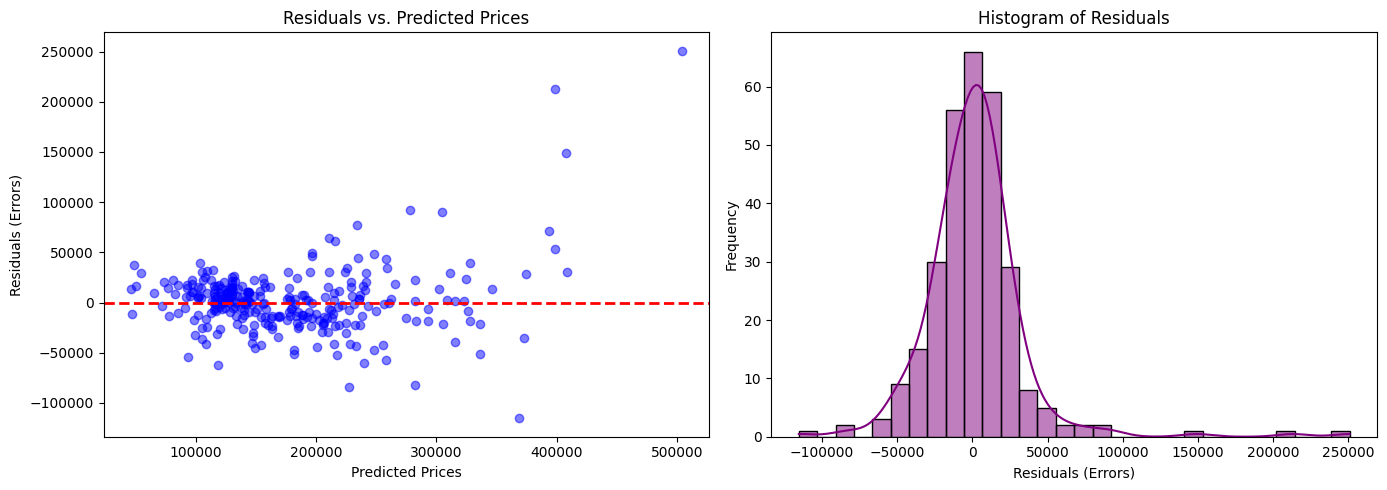

In [10]:
# Task 13 — compute and plot residuals
import seaborn as sns
# 1. Compute Residuals
residuals = y_test - y_pred

# 2. Set up the figure for 2 plots side-by-side
plt.figure(figsize=(14, 5))

# Plot A: Residuals vs Predicted Values (Scatter Plot)
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2) # 0 Error line
plt.title('Residuals vs. Predicted Prices')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Errors)')

# Plot B: Histogram of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals (Errors)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Answer 13:**
Scatter Plot: The residuals are not perfectly randomly scattered. While they are tightly clustered around the zero-line for lower-priced houses (between 100k and 200k), the spread widens significantly as the predicted prices increase. This visible "funnel" shape indicates heteroscedasticity, meaning the model's errors are larger when predicting the prices of more expensive properties.

Histogram: The histogram is generally centered around zero, indicating that most errors are small. However, there is a visible right skew (a longer tail on the right side), which is caused by the model heavily under-predicting the prices of a few very expensive outlier houses.

---

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [11]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Taking the square root of MSE
r2 = r2_score(y_test, y_pred)

# 2. Create a small table (DataFrame) to report them
metrics_df = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R²)'],
    'Value': [mae, mse, rmse, r2]
})

# Display the table
print("--- Model Performance Metrics ---")
metrics_df

--- Model Performance Metrics ---


,Metric,Value
0,Mean Absolute Error (MAE),2.065186e+04
1,Mean Squared Error (MSE),1.100246e+09
2,Root Mean Squared Error (RMSE),3.316995e+04
3,R-squared (R²),8.565581e-01


**Task 14 — Test Set Metrics**

|index|Metric|Value|
|---|---|---|
|0|Mean Absolute Error \(MAE\)|20651\.85901714137|
|1|Mean Squared Error \(MSE\)|1100245903\.0044029|
|2|Root Mean Squared Error \(RMSE\)|33169\.95482367142|
|3|R-squared \(R²\)|0\.856558134128185|

**Answer 15:**
### What Each Metric Tells Us

* **MAE:** Average prediction error, in dollars. Easy to understand.
* **MSE:** Average squared error. Gives more weight to large errors.
* **RMSE:** Error in dollars, with more focus on large errors.
* **R²:** How much of the price variation the model explains.

### Best Metric for a Non-Technical Stakeholder

**MAE** is the best choice because it is simple and intuitive.
For example: **“Our predictions are off by about $X on average.”**


---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [12]:
# Task 16 — compute training-set metrics
# 1. Model se Training Data (X_train) par qeematein predict karwayein
y_train_pred = model.predict(X_train)

# 2. Training data ki metrics calculate karein
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# 3. Train aur Test metrics ko aamne-saamne rakhne ke liye DataFrame banayein
performance_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Training Performance': [train_mae, train_mse, train_rmse, train_r2],
    'Testing Performance': [mae, mse, rmse, r2]  # Yeh variables humne Task 14 mein banaye thay
})

# Table display karein
print("--- Training vs. Testing Performance ---")
performance_df

--- Training vs. Testing Performance ---


,Metric,Training Performance,Testing Performance
0,MAE,1.931763e+04,2.065186e+04
1,MSE,9.960574e+08,1.100246e+09
2,RMSE,3.156038e+04,3.316995e+04
3,R²,8.330038e-01,8.565581e-01


**Task 16 — Train vs. Test Comparison**

|index|Metric|Training Performance|Testing Performance|
|---|---|---|---|
|0|MAE|19317\.63380558751|20651\.85901714137|
|1|MSE|996057378\.7805401|1100245903\.0044029|
|2|RMSE|31560\.376721144192|33169\.95482367142|
|3|R²|0\.8330037780955308|0\.856558134128185|
**Answer 17:**
Is there a large gap between training and testing performance?
No, there is no large gap between the training and testing performance. In fact, the metrics are very close. For example, the Training RMSE is roughly $31,560 while the Testing RMSE is about $33,169. Interestingly, the R² score on the testing set (0.856) is slightly higher than on the training set (0.833), which can sometimes happen depending on the data split, but it confirms the scores are highly comparable.

What would a large gap suggest, and what does our result suggest?
A large gap—specifically where training errors are very low but testing errors are very high—would strongly suggest Overfitting (meaning the model memorized the training data's noise and failed to generalize).

Because our actual results show very similar metrics across both sets, it suggests that our model generalizes very well. It has successfully learned the underlying patterns of the housing market without overfitting to the specific training example

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**
### Model Interpretation

The most influential features appear to be **Neighborhood_ClearCr, OverallQual, and GarageCars** based on their coefficient magnitudes.

However, coefficient size alone does not determine importance because features have different scales. For example, **GarageCars** has a coefficient of about **$11,289**, so adding one garage space may increase the predicted price by about $11,289. In contrast, **GrLivArea** has a smaller coefficient of about **$43.66 per sq. ft.**, but an extra **500 sq. ft.** could add about **$21,830** to the predicted price.

Therefore, feature importance should be considered along with the **scale and typical range** of each feature.


---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

In [13]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv
import pandas as pd

# 1. Load the Kaggle test data
test_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

# 2. Save the 'Id' column for the final submission format
test_ids = test_df['Id']

# Drop the 'Id' column from features to match training data
X_test_kaggle = test_df.drop('Id', axis=1, errors='ignore')

# 3. Apply the same One-Hot Encoding used on the training data
X_test_encoded = pd.get_dummies(X_test_kaggle)

# 4. Align columns: Ensure test data has exactly the same columns as X_train
# This fills missing columns with 0 and removes any extra columns not in train
X_test_aligned = X_test_encoded.reindex(columns=X_train.columns, fill_value=0)

# Fill any remaining missing (NaN) values with 0
X_test_aligned = X_test_aligned.fillna(0)

# 5. Predict SalePrice for every row
final_predictions = model.predict(X_test_aligned)

# 6. Build the final DataFrame with exactly two columns: Id and SalePrice
submission_df = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_predictions
})

# 7. Save to 'submission.csv'
submission_df.to_csv('submission.csv', index=False)

print("Success! 'submission.csv' is ready to be uploaded to Kaggle.")

Success! 'submission.csv' is ready to be uploaded to Kaggle.


**Answer 21 — Kaggle Leaderboard Result:**

Public score: 0.1567

Rank: 2456

Reflection (1–2 sentences): Achieving a score of 0.1567 and a rank of 2456 is a solid baseline achievement that proves my data preparation and linear regression pipeline is functioning perfectly. It also highlights that while a linear approach captures the primary trends, there is clear room to improve the rank by applying advanced feature engineering and non-linear models in the future.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Exploration
- [ ] Section 3 — Feature and Target Identification
- [ ] Section 4 — Data Preparation (encoding justified)
- [ ] Section 5 — Train/Test Split
- [ ] Section 6 — Linear Regression Model
- [ ] Section 7 — Predictions (actual vs. predicted table)
- [ ] Section 8 — Coefficients and Intercept (full table + interpretation)
- [ ] Section 9 — Residual Analysis (plots + discussion)
- [ ] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [ ] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [ ] Section 12 — Model Interpretation (most influential features)
- [ ] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted